## 1) Load Data

Load data, filter by removing unnecessary columns(data), and process the rest of it

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.signal import find_peaks
import numpy as np
import pandas as pd
import re

In [2]:
# Reset to default white theme and explicitly set face colors instead of using system theme colors
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'

In [ ]:
pwd

In [3]:
# FILE_DIR = str(Path('path')) # Replace 'path' with the actual path to your directory

FILES_DIR = [str(path) for path in Path('videos_jetson').glob('*.csv')]
FILES_DIR.sort()

In [50]:
FILES_DIR

['videos_jetson/rotated_exp_20260917_143617DLC_Resnet50_Stick_Insect_Motion_Hacking_2D_TrackingSep21shuffle2_snapshot_1000.csv',
 'videos_jetson/rotated_exp_20260917_144243DLC_Resnet50_Stick_Insect_Motion_Hacking_2D_TrackingSep21shuffle2_snapshot_1000.csv',
 'videos_jetson/rotated_exp_20260917_150406_ind01_01DLC_Resnet50_Stick_Insect_Motion_Hacking_2D_TrackingSep21shuffle2_snapshot_1000.csv',
 'videos_jetson/rotated_exp_20260917_150454_ind01_02DLC_Resnet50_Stick_Insect_Motion_Hacking_2D_TrackingSep21shuffle2_snapshot_1000.csv',
 'videos_jetson/rotated_exp_20260917_150631_ind01_02DLC_Resnet50_Stick_Insect_Motion_Hacking_2D_TrackingSep21shuffle2_snapshot_1000.csv',
 'videos_jetson/rotated_exp_20260917_150709_ind01_03DLC_Resnet50_Stick_Insect_Motion_Hacking_2D_TrackingSep21shuffle2_snapshot_1000.csv',
 'videos_jetson/rotated_exp_20260917_150809_ind01_04DLC_Resnet50_Stick_Insect_Motion_Hacking_2D_TrackingSep21shuffle2_snapshot_1000.csv',
 'videos_jetson/rotated_exp_20260917_153655_ind01_05

In [4]:
# Map results, give a legend color,
trial_map = {0: {'trial_detail': 'Others', 'color': "#a734d5"},
             1: {'trial_detail': 'Random (No Stimulation)', 'color': '#f77189'},
             2: {'trial_detail': 'Random (No Stimulation)', 'color': '#f77189'},
             3: {'trial_detail': 'Random (No Stimulation)', 'color': '#f77189'},
             4: {'trial_detail': 'Random (No Stimulation)', 'color': '#f77189'}, 
             5: {'trial_detail': '0.1s with 1.0s period (T)', 'color': '#e68332'},
             6: {'trial_detail': '0.1s with 1.0s period (T)', 'color': '#e68332'},
             7: {'trial_detail': '0.5s with 1.5s period (T)', 'color': '#bb9832'},
             8: {'trial_detail': '0.5s with 1.5s period (T)', 'color': '#bb9832'},
             9: {'trial_detail': '1.0s with 2.0s period (T)', 'color': '#97a431'},
             10: {'trial_detail': '1.0s with 2.0s period (T)', 'color': '#97a431'},
             11: {'trial_detail': '1.5s with 2.5s period (T)', 'color': '#50b131'},
             12: {'trial_detail': '1.5s with 2.5s period (T)', 'color': '#50b131'},
             13: {'trial_detail': '2.0s with 3.0s period (T)', 'color': '#34af84'},
             14: {'trial_detail': '2.0s with 3.0s period (T)', 'color': '#34af84'},
             15: {'trial_detail': '2.5s with 3.5s period (T)', 'color': '#36ada4'},
             16: {'trial_detail': '2.5s with 3.5s period (T)', 'color': '#36ada4'},
             17: {'trial_detail': '3.0s with 4.0s period (T)', 'color': '#38aabf'},
             18: {'trial_detail': '3.0s with 4.0s period (T)', 'color': '#38aabf'},
             19: {'trial_detail': '3.5s with 4.5s period (T)', 'color': '#3ba3ec'},
             20: {'trial_detail': '3.5s with 4.5s period (T)', 'color': '#3ba3ec'},
             21: {'trial_detail': '4.0s with 5.0s period (T)', 'color': '#a48cf4'},
             22: {'trial_detail': '4.0s with 5.0s period (T)', 'color': '#a48cf4'},
             23: {'trial_detail': '4.5s with 5.5s period (T)', 'color': '#e866f4'},
             24: {'trial_detail': '4.5s with 5.5s period (T)', 'color': '#e866f4'},
             25: {'trial_detail': '5.0s with 6.0s period (T)', 'color': '#f668c2'},
             26: {'trial_detail': '5.0s with 6.0s period (T)', 'color': '#f668c2'},
             27: {'trial_detail': '0.2s with 1.5s period (T)', 'color': '#110539'},
             28: {'trial_detail': '0.2s with 1.5s period (T)', 'color': '#110539'},
             29: {'trial_detail': '0.3s with 1.5s period (T)', 'color': '#850913'},
             30: {'trial_detail': '0.3s with 1.5s period (T)', 'color': '#850913'},
             31: {'trial_detail': '0.4s with 1.5s period (T)', 'color': '#edfa58'},
             32: {'trial_detail': '0.4s with 1.5s period (T)', 'color': '#edfa58'},
             33: {'trial_detail': '0.6s with 1.5s period (T)', 'color': '#cd4948'},
             34: {'trial_detail': '0.6s with 1.5s period (T)', 'color': '#cd4948'},
             35: {'trial_detail': '0.7s with 1.5s period (T)', 'color': '#58ea70'},
             36: {'trial_detail': '0.7s with 1.5s period (T)', 'color': '#58ea70'},
             37: {'trial_detail': '0.8s with 1.5s period (T)', 'color': '#7f963f'},
             38: {'trial_detail': '0.8s with 1.5s period (T)', 'color': '#7f963f'},
             39: {'trial_detail': '0.9s with 1.5s period (T)', 'color': '#c9362e'},
             40: {'trial_detail': '0.9s with 1.5s period (T)', 'color': '#c9362e'},
             41: {'trial_detail': 'Manual Stimulation', 'color': '#1acbc5'},
             42: {'trial_detail': 'Manual Stimulation', 'color': '#1acbc5'},
             43: {'trial_detail': '0.5s with 1s period (T), 10% Duty Ratio', 'color': '#8d88db'},
             44: {'trial_detail': '0.5s with 1s period (T), 20% Duty Ratio', 'color': '#222283'},
             45: {'trial_detail': '0.5s with 1s period (T), 30% Duty Ratio', 'color': '#ec71e1'},
             46: {'trial_detail': '0.5s with 1s period (T), 40% Duty Ratio', 'color': '#0c9a4b'},
             47: {'trial_detail': '0.5s with 1s period (T), 50% Duty Ratio', 'color': '#a4edc5'},
             48: {'trial_detail': '0.5s with 1.5s period (T), 1280x720 Resolution', 'color': "#ede3a4"},
             49: {'trial_detail': '1.0s with 2.0s period (T), 1280x720 Resolution', 'color': "#aaa4ed"},
             50: {'trial_detail': '2.0s with 3.0s period (T), 1280x720 Resolution', 'color': "#eda4e0"},
             51: {'trial_detail': '2.0s with 3.0s period (T), 1280x720 Resolution', 'color': "#875039"},
             110: {'trial_detail': 'Auto Exposure', 'color': "#e84d4d"},
             120: {'trial_detail': 'Manual Exposure (Exposure 70)', 'color': "#4b1904"},
             130: {'trial_detail': 'Manual Exposure (Exposure 70, Light 20)', 'color': "#066309"},
             140: {'trial_detail': 'Manual Exposure (Exposure 70, Light 50)', 'color': "#25b3b8"},
             }


In [5]:
for file in FILES_DIR:
    df = pd.read_csv(file)

    special_overrides = {
    '011': '110',  # Mapped formatted string
    '012': '120',
    '013': '130',
    '014': '140',
    }

    # Extract trial label (e.g. '01', '02', '14', etc.)
    match = re.search(r'ind(?:_)?01_(\d+)', file)
    if match:
        raw_id = match.group(1)  # e.g., '07' or '071'
    
        # Insert decimal point if ID has 3 or more digits ('071' -> '07.1')
        if raw_id in ('011','012', '013', '014'):
            formatted_id = special_overrides[raw_id]
        elif len(raw_id) >= 3:
            formatted_id = f"{raw_id[:-1]}.{raw_id[-1]}"
        else:
            formatted_id = raw_id
        
        trial_num = float(formatted_id)       # 7.1 (allows range check 7 <= 7.1 <= 26)
        base_trial = int(trial_num)          # 7 (used to lookup key in trial_map)
        trial_label = f"Trial {formatted_id}"  # "Trial 07.1"
    else:
        trial_num = None
        base_trial = None
        trial_label = "Test"

In [ ]:
output_folder = Path('trial_plots')
output_folder.mkdir(parents=True, exist_ok=True)

for file in FILES_DIR:
    df = pd.read_csv(file)

    special_overrides = {
    '011': '110',  # Mapped formatted string
    '012': '120',
    '013': '130',
    '014': '140',
    }

    # Extract trial label (e.g. '01', '02', '14', etc.)
    match = re.search(r'ind(?:_)?01_(\d+)', file)
    if match:
        raw_id = match.group(1)  # e.g., '07' or '071'
    
        # Insert decimal point if ID has 3 or more digits ('071' -> '07.1')
        if raw_id in ('011','012', '013', '014'):
            formatted_id = special_overrides[raw_id]
        elif len(raw_id) >= 3:
            formatted_id = f"{raw_id[:-1]}.{raw_id[-1]}"
        else:
            formatted_id = raw_id
        
        trial_num = float(formatted_id)       # 7.1 (allows range check 7 <= 7.1 <= 26)
        base_trial = int(trial_num)          # 7 (used to lookup key in trial_map)
        trial_label = f"Trial {formatted_id}"  # "Trial 07.1"
    else:
        trial_num = None
        base_trial = None
        trial_label = "Test"

    # Extract body parts and coordinates from the first two rows
    bodyparts= df.iloc[0,1:]
    coords = df.iloc[1,1:]

    df_filtered = df.iloc[2:].reset_index(drop=True) # remove the first two rows which are not needed

    flat_cols = ['frame'] + [
        f'{bp}_{c}' for bp, c in zip(bodyparts, coords)
    ]

    df_filtered.columns = flat_cols
    df_filtered = df_filtered.astype({col: float for col in df_filtered.columns if col != 'frame'})
    df_filtered.drop(list(df_filtered.filter(regex='likelihood')), axis=1, inplace=True)


    # Calculate the angle between the TCTC and TCFT vectors
    df_filtered['TCTC_vector_x'] = df_filtered['TC_Middle_Leg_x'] - df_filtered['TC_Front_Leg_x'] 
    df_filtered['TCTC_vector_y'] = df_filtered['TC_Middle_Leg_y'] - df_filtered['TC_Front_Leg_y']

    df_filtered['TCFT_vector_x'] = df_filtered['TC_Middle_Leg_x'] - df_filtered['FT_Middle_Leg_x']
    df_filtered['TCFT_vector_y'] = df_filtered['TC_Middle_Leg_y'] - df_filtered['FT_Middle_Leg_y']

    # Dot product and magnitudes of the two vectors to get the cosine of the angle between them
    df_filtered['dot_product'] = df_filtered['TCTC_vector_x'] * df_filtered['TCFT_vector_x'] + df_filtered['TCTC_vector_y'] * df_filtered['TCFT_vector_y']

    df_filtered['TCTC_magnitude'] = (df_filtered['TCTC_vector_x']**2 + df_filtered['TCTC_vector_y']**2)**0.5
    df_filtered['TCFT_magnitude'] = (df_filtered['TCFT_vector_x']**2 + df_filtered['TCFT_vector_y']**2)**0.5


    df_filtered['cosine_angle'] = (df_filtered['dot_product'] / (df_filtered['TCTC_magnitude'] * df_filtered['TCFT_magnitude'])).clip(-1.0, 1.0)
    df_filtered['angle'] = np.arccos(df_filtered['cosine_angle']) * 180 / np.pi


    # Plot angle over time
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 
                                             1, 
                                             figsize=(28, 16), 
                                             layout='constrained',
                                             gridspec_kw={'height_ratios': [1, 2, 1, 1]})


    # Title for entire figure
    fig.suptitle(f"Trial {trial_num} - {trial_map[int(trial_num)]['trial_detail'] if trial_num is not None else 'Test'}", fontsize=16, fontweight='bold')

    # Convert frames into seconds
    df_filtered['time'] =  pd.to_numeric(df_filtered['frame'], errors='coerce') / 60  # Assuming 60 FPS    

    # Coordinates over time
    ax1.plot(df_filtered['time'], df_filtered['TC_Middle_Leg_x'], label='TC_Middle_Leg X', color='red', alpha=0.7)
    ax1.plot(df_filtered['time'], df_filtered['TC_Middle_Leg_y'], label='TC_Middle_Leg Y', color='blue', alpha=0.7)
    ax1.plot(df_filtered['time'], df_filtered['FT_Middle_Leg_x'], label='FT_Middle_Leg X', color='darkred', linestyle='--')
    ax1.plot(df_filtered['time'], df_filtered['FT_Middle_Leg_y'], label='FT_Middle_Leg Y', color='darkblue', linestyle='--')

    
    ax1.set_title('Coordinates of TC and FT Middle Legs Over Time')
    ax1.set_ylabel('Coordinates')
    ax1.set_xlabel('Time (s)')
    ax1.legend()

    # Spatial trajectory of keypoints
    ax2.plot(df_filtered['TC_Front_Leg_x'], df_filtered['TC_Front_Leg_y'], color='blue')
    ax2.plot(df_filtered['TC_Middle_Leg_x'], df_filtered['TC_Middle_Leg_y'], color='green')
    ax2.plot(df_filtered['FT_Middle_Leg_x'], df_filtered['FT_Middle_Leg_y'], color='red')

    ax2.set_title('Spatial Trajectory of Keypoints')
    ax2.set_xlabel('X Coordinate')
    ax2.set_ylabel('Y Coordinate')
    ax2.invert_yaxis()  # Invert y-axis to match image coordinate system
    ax2.set_aspect('equal', adjustable='box')
    ax2.grid(True, alpha=0.3)

    # Angle over time
    ax3.plot(df_filtered['time'], df_filtered['angle'], color='purple')
    ax3.set_title('Angle Between TCTC and TCFT Vectors Over Time')
    ax3.set_xlabel('Time (s)')
    ax3.set_ylabel('Angle (degrees)')

    ax3.set_xlim(0, 20)  # Set x-axis limit for time from 0 to 20 seconds

    # Angle difference
    # Collect peak differences and labels for each group
    angle_signal = df_filtered['angle'].dropna().values
    peaks, properties = find_peaks(angle_signal, prominence=1)
    peak_prominences = properties['prominences']

    if len(peak_prominences) > 0:
        # horizontal Violin Plot (vert=False) placed at y = 1
        parts = ax4.violinplot([peak_prominences], positions=[1], vert=False, showmeans=True, showmedians=False)
        
        # Custom styling
        for pc in parts['bodies']:
            pc.set_facecolor('purple')
            pc.set_edgecolor('black')
            pc.set_alpha(0.3)
            
        # add vertical jitter around y = 1 (X stays exact, Y varies slightly)
        y_coords = np.random.normal(loc=1.0, scale=0.04, size=len(peak_prominences))
        ax4.scatter(peak_prominences, y_coords, alpha=0.7, s=50, color='darkblue', edgecolors='w', zorder=3)

    # 4. Axes Formatting
    ax4.set_yticks([1])
    ax4.set_yticklabels([f'{trial_label}'])
    ax4.set_ylim(0.5, 1.5)  # Keeps the trial centered along the Y-axis

    ax4.set_xlabel('Peak Amplitude / Difference (degrees)', fontsize=12)
    ax4.set_ylabel('Trial', fontsize=12)
    ax4.set_title(f"Peak Amplitude Distribution - {trial_label} ({trial_map[int(trial_num)]['trial_detail'] if trial_num is not None else 'Test'})", fontsize=14, pad=15)
    ax4.grid(True, axis='x', linestyle=':', alpha=0.6)

    plt.subplots_adjust(hspace=0.6) 
    # Save figure
    fig_path = output_folder / f"plot_wave_{trial_label}.png"
    fig.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.tight_layout()

[{'Trial_Num': 1.0, 'Trial': 'Trial 01', 'Peak_Difference': 3.954271461357493, 'color': '#f77189', 'trial_legend': 'Random (No Stimulation)'}, {'Trial_Num': 1.0, 'Trial': 'Trial 01', 'Peak_Difference': 81.25950067907927, 'color': '#f77189', 'trial_legend': 'Random (No Stimulation)'}, {'Trial_Num': 1.0, 'Trial': 'Trial 01', 'Peak_Difference': 57.02729186332871, 'color': '#f77189', 'trial_legend': 'Random (No Stimulation)'}, {'Trial_Num': 1.0, 'Trial': 'Trial 01', 'Peak_Difference': 8.143923750182552, 'color': '#f77189', 'trial_legend': 'Random (No Stimulation)'}, {'Trial_Num': 1.0, 'Trial': 'Trial 01', 'Peak_Difference': 84.9341900205282, 'color': '#f77189', 'trial_legend': 'Random (No Stimulation)'}, {'Trial_Num': 1.0, 'Trial': 'Trial 01', 'Peak_Difference': 4.581403857355653, 'color': '#f77189', 'trial_legend': 'Random (No Stimulation)'}, {'Trial_Num': 1.0, 'Trial': 'Trial 01', 'Peak_Difference': 16.018016590084414, 'color': '#f77189', 'trial_legend': 'Random (No Stimulation)'}, {'Tri

/tmp/ipykernel_5301/1795437591.py:187: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


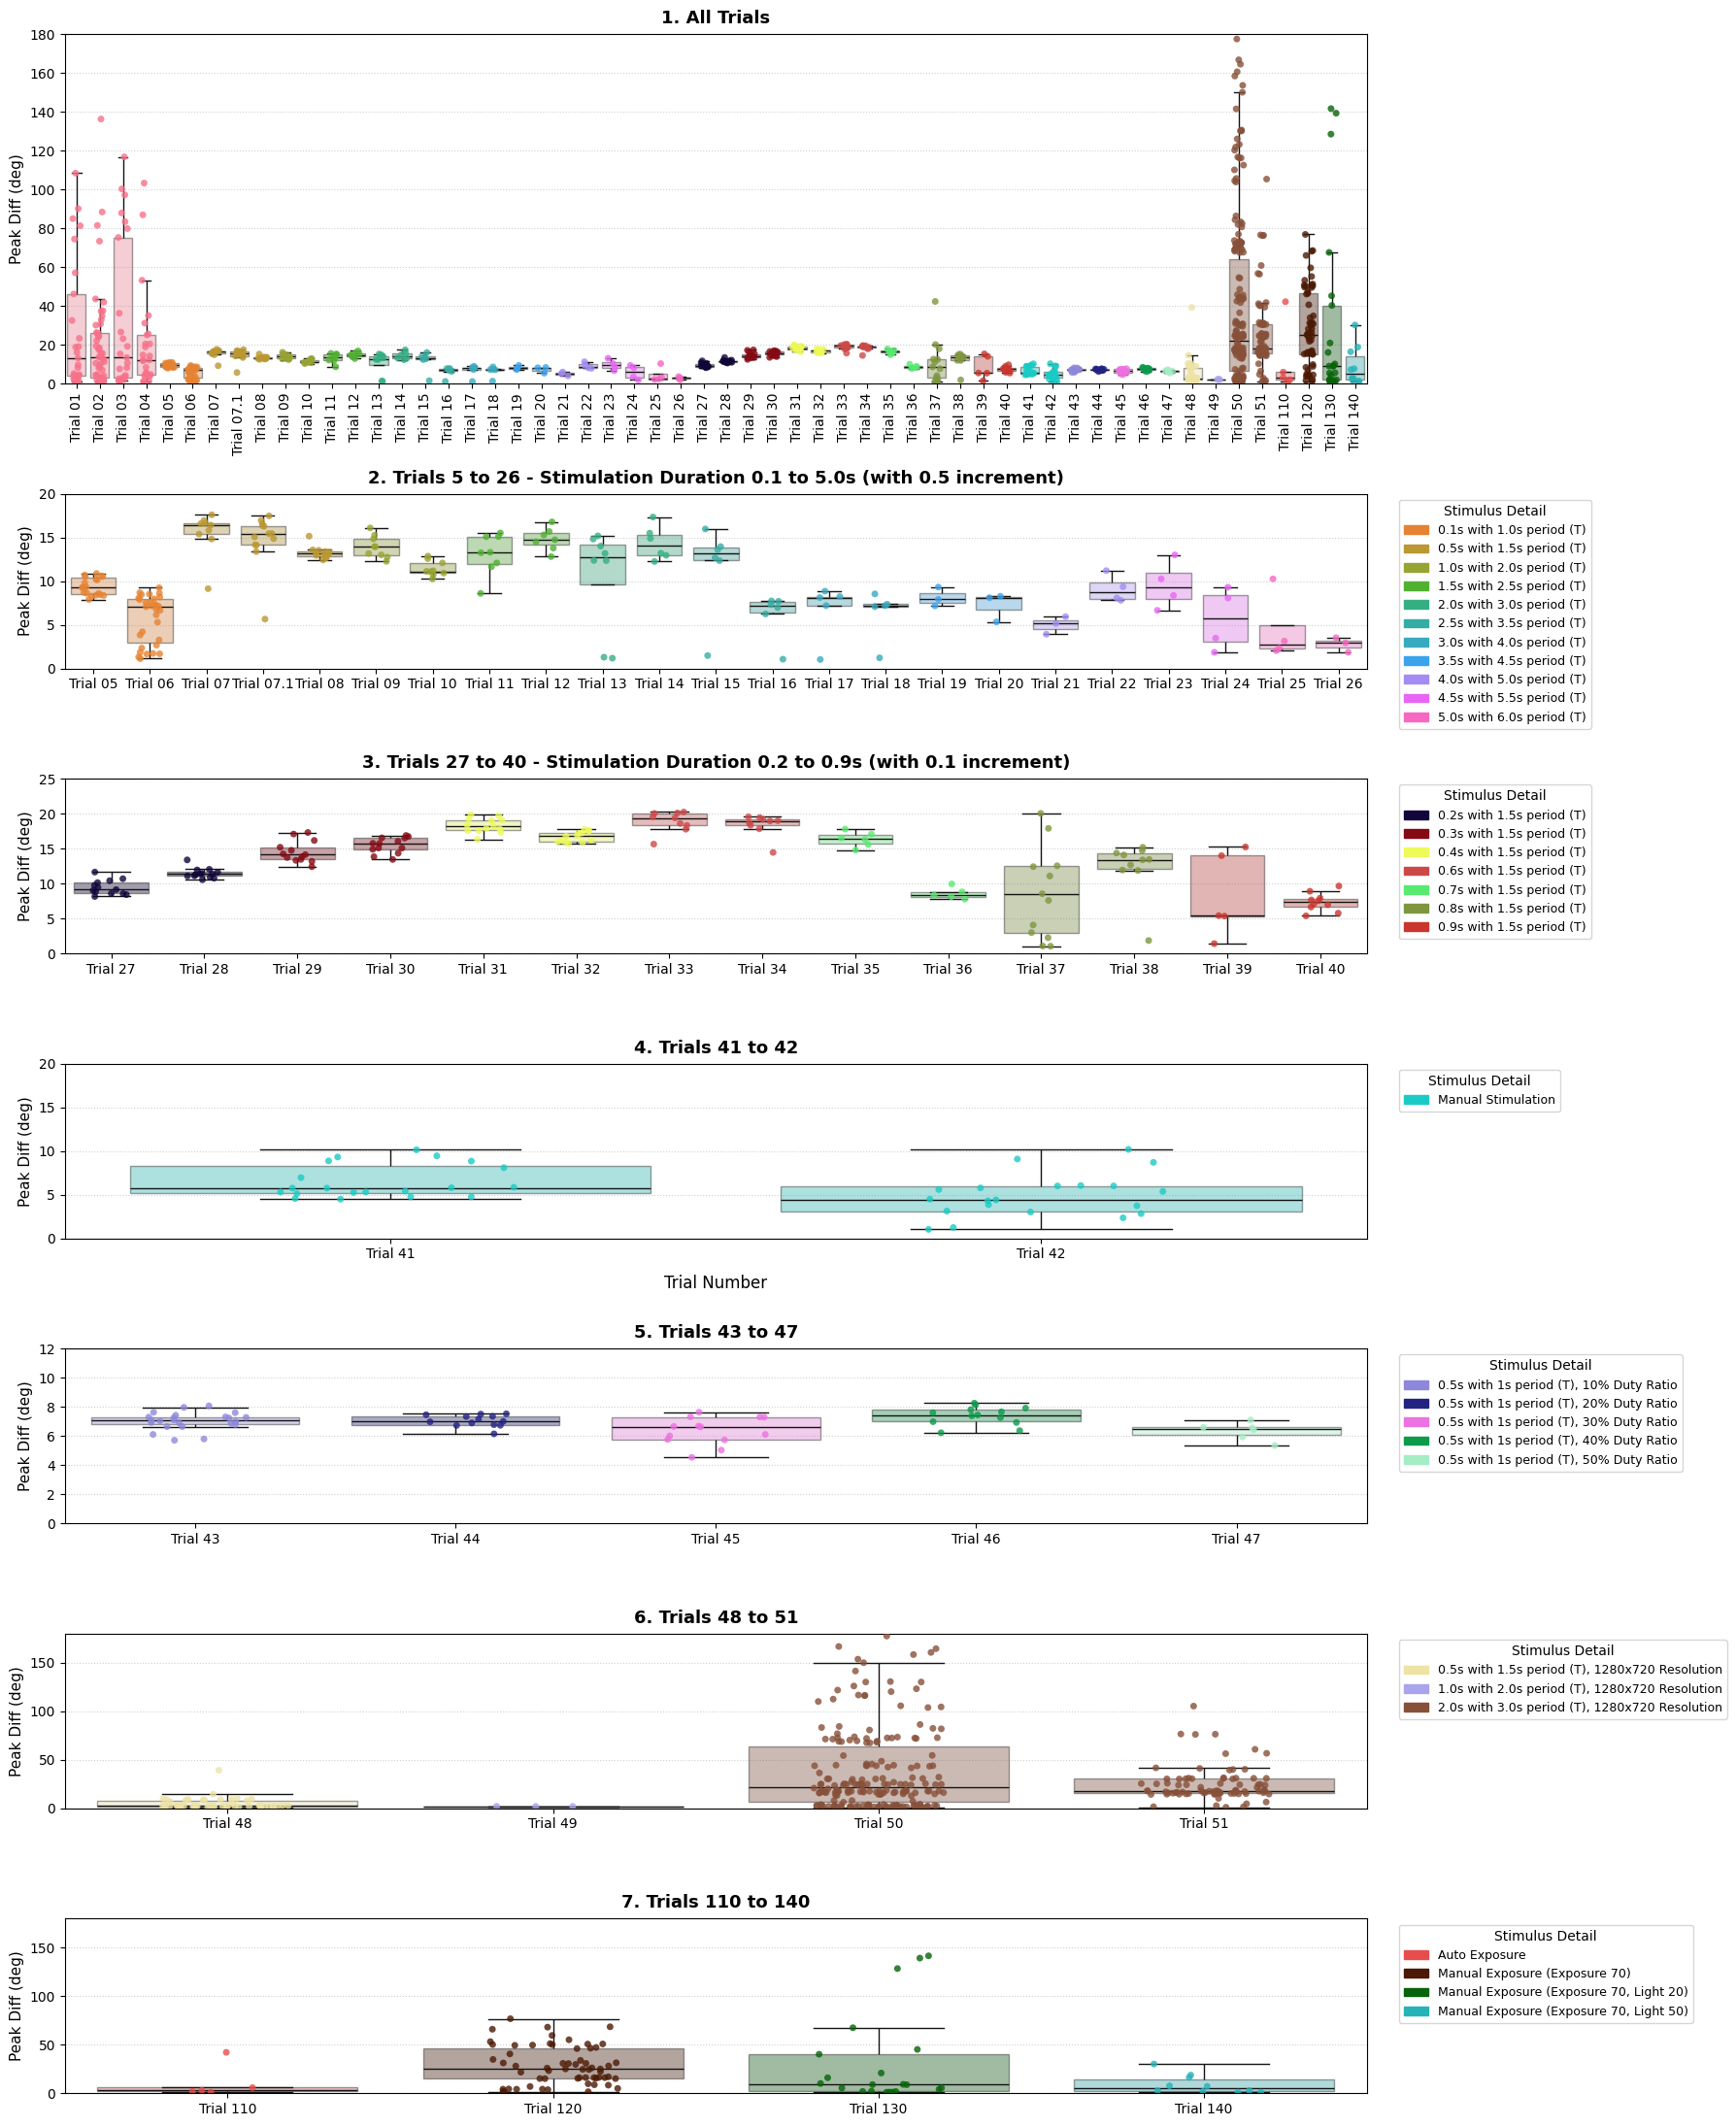

In [ ]:
records = []

for file in FILES_DIR:
    df = pd.read_csv(file)

    special_overrides = {
    '011': '110',  # Mapped formatted string
    '012': '120',
    '013': '130',
    '014': '140',
    }

    # Extract trial label (e.g. '01', '02', '14', etc.)
    match = re.search(r'ind(?:_)?01_(\d+)', file)
    if match:
        raw_id = match.group(1)  # e.g., '07' or '071'
    
        # Insert decimal point if ID has 3 or more digits ('071' -> '07.1')
        if raw_id in ('011','012', '013', '014'):
            formatted_id = special_overrides[raw_id]
        elif len(raw_id) >= 3:
            formatted_id = f"{raw_id[:-1]}.{raw_id[-1]}"
        else:
            formatted_id = raw_id
        
        trial_num = float(formatted_id)       # 7.1 (allows range check 7 <= 7.1 <= 26)
        base_trial = int(trial_num)          # 7 (used to lookup key in trial_map)
        trial_label = f"Trial {formatted_id}"  # "Trial 07.1"
    else:
        trial_num = None
        base_trial = None
        trial_label = "Test"

    # Extract body parts and coordinates from the first two rows
    bodyparts= df.iloc[0,1:]
    coords = df.iloc[1,1:]

    df_filtered = df.iloc[2:].reset_index(drop=True) # remove the first two rows which are not needed

    flat_cols = ['frame'] + [
        f'{bp}_{c}' for bp, c in zip(bodyparts, coords)
    ]

    df_filtered.columns = flat_cols
    df_filtered = df_filtered.astype({col: float for col in df_filtered.columns if col != 'frame'})
    df_filtered.drop(list(df_filtered.filter(regex='likelihood')), axis=1, inplace=True)


    # Calculate the angle between the TCTC and TCFT vectors
    df_filtered['TCTC_vector_x'] = df_filtered['TC_Middle_Leg_x'] - df_filtered['TC_Front_Leg_x'] 
    df_filtered['TCTC_vector_y'] = df_filtered['TC_Middle_Leg_y'] - df_filtered['TC_Front_Leg_y']

    df_filtered['TCFT_vector_x'] = df_filtered['TC_Middle_Leg_x'] - df_filtered['FT_Middle_Leg_x']
    df_filtered['TCFT_vector_y'] = df_filtered['TC_Middle_Leg_y'] - df_filtered['FT_Middle_Leg_y']

    # Dot product and magnitudes of the two vectors to get the cosine of the angle between them
    df_filtered['dot_product'] = df_filtered['TCTC_vector_x'] * df_filtered['TCFT_vector_x'] + df_filtered['TCTC_vector_y'] * df_filtered['TCFT_vector_y']

    df_filtered['TCTC_magnitude'] = (df_filtered['TCTC_vector_x']**2 + df_filtered['TCTC_vector_y']**2)**0.5
    df_filtered['TCFT_magnitude'] = (df_filtered['TCFT_vector_x']**2 + df_filtered['TCFT_vector_y']**2)**0.5


    df_filtered['cosine_angle'] = (df_filtered['dot_product'] / (df_filtered['TCTC_magnitude'] * df_filtered['TCFT_magnitude'])).clip(-1.0, 1.0)
    df_filtered['angle'] = np.arccos(df_filtered['cosine_angle']) * 180 / np.pi

    # Find angle difference
    angle_signal = df_filtered['angle'].dropna().values
    peaks, properties = find_peaks(angle_signal, prominence=1)
    prominences = properties['prominences']

    
    for p in prominences:
        if trial_num is None:
            continue
        
        records.append({
            'Trial_Num': trial_num,
            'Trial': trial_label,
            'Peak_Difference': p,
            'color': trial_map[int(trial_num)]['color'],
            'trial_legend': trial_map[int(trial_num)]['trial_detail'],
        })

summary_df = pd.DataFrame(records)
color_palette = dict(zip(summary_df['trial_legend'], summary_df['color']))


# Plot angle over time
fig, (ax1, ax2, ax3, ax4, ax5, ax6, ax7) = plt.subplots(
    7,
    1,
    figsize=(18, 22),
    layout='constrained',
    gridspec_kw={'height_ratios': [2, 1, 1, 1, 1, 1, 1]},
)

# Add new column to select the modified trial names
if 'Base_Key' not in summary_df.columns:
    summary_df['Base_Key'] = summary_df['Trial_Num'].apply(
        lambda x: int(x)
    )

subplot_configs = [
    ("1. All Trials", None, None, ax1, (0, 180)),
    ("2. Trials 5 to 26 - Stimulation Duration 0.1 to 5.0s (with 0.5 increment)", 5, 26, ax2, (0, 20)),
    ("3. Trials 27 to 40 - Stimulation Duration 0.2 to 0.9s (with 0.1 increment)", 27, 40, ax3, (0, 25)),
    ("4. Trials 41 to 42", 41, 42, ax4, (0, 20)),
    ("5. Trials 43 to 47", 43, 47, ax5, (0, 12)),
    ("6. Trials 48 to 51", 48, 51, ax6, (0, 180)),
    ("7. Trials 110 to 140", 110, 140, ax7, (0, 180))
]

for title, min_k, max_k, ax, ylim in subplot_configs:
    # Filter dataframe by range
    if min_k is None and max_k is None:
        sub_df = summary_df.copy()
    else:
        sub_df = summary_df[(summary_df['Base_Key'] >= min_k) & (summary_df['Base_Key'] <= max_k)]
    
    if sub_df.empty:
        ax.set_title(f"{title} (No Data Available)", fontsize=12)
        continue

    # Boxplot
    sns.boxplot(
        data=sub_df, 
        x='Trial', 
        y='Peak_Difference', 
        hue='trial_legend',      
        palette=color_palette,   
        dodge=False,
        boxprops=dict(alpha=0.4),
        showfliers=False,
        legend=False,            # Suppress subplot legend to prevent clutter
        ax=ax
    )

    # Stripplot
    sns.stripplot(
        data=sub_df, 
        x='Trial', 
        y='Peak_Difference', 
        hue='trial_legend', 
        palette=color_palette, 
        dodge=False, 
        size=5, 
        jitter=0.2, 
        alpha=0.8,
        legend=False,
        ax=ax
    )

    if ax != ax1:
        sub_palette = dict(zip(sub_df['trial_legend'], sub_df['color']))
        sub_patches = [
            mpatches.Patch(color=c, label=l) 
            for l, c in sub_palette.items()
        ]
        
        ax.legend(
            handles=sub_patches,
            title='Stimulus Detail',
            bbox_to_anchor=(1.02, 1), # Places legend just outside the right edge of the subplot
            loc='upper left',
            fontsize=9,
            title_fontsize=10,
            frameon=True
        )

    # Subplot Formatting
    ax.set_title(title, fontsize=13, pad=8, weight='bold')
    ax.set_xlabel('')
    if ax is not ax1:
        ax.set_ylim(0,20)
        ax.tick_params(axis='x', rotation=0)
    else:
        ax.tick_params(axis='x', rotation=90)
    ax.set_ylabel('Peak Diff (deg)', fontsize=11)
    
    ax.set_ylim(ylim)
    ax.grid(True, axis='y', linestyle=':', alpha=0.6)

# Label X-axis on the bottom subplot only
ax4.set_xlabel('Trial Number', fontsize=12, labelpad=10)

plt.tight_layout()
plt.savefig('all_trials_full_column_ticks.png', dpi=300)
plt.show()

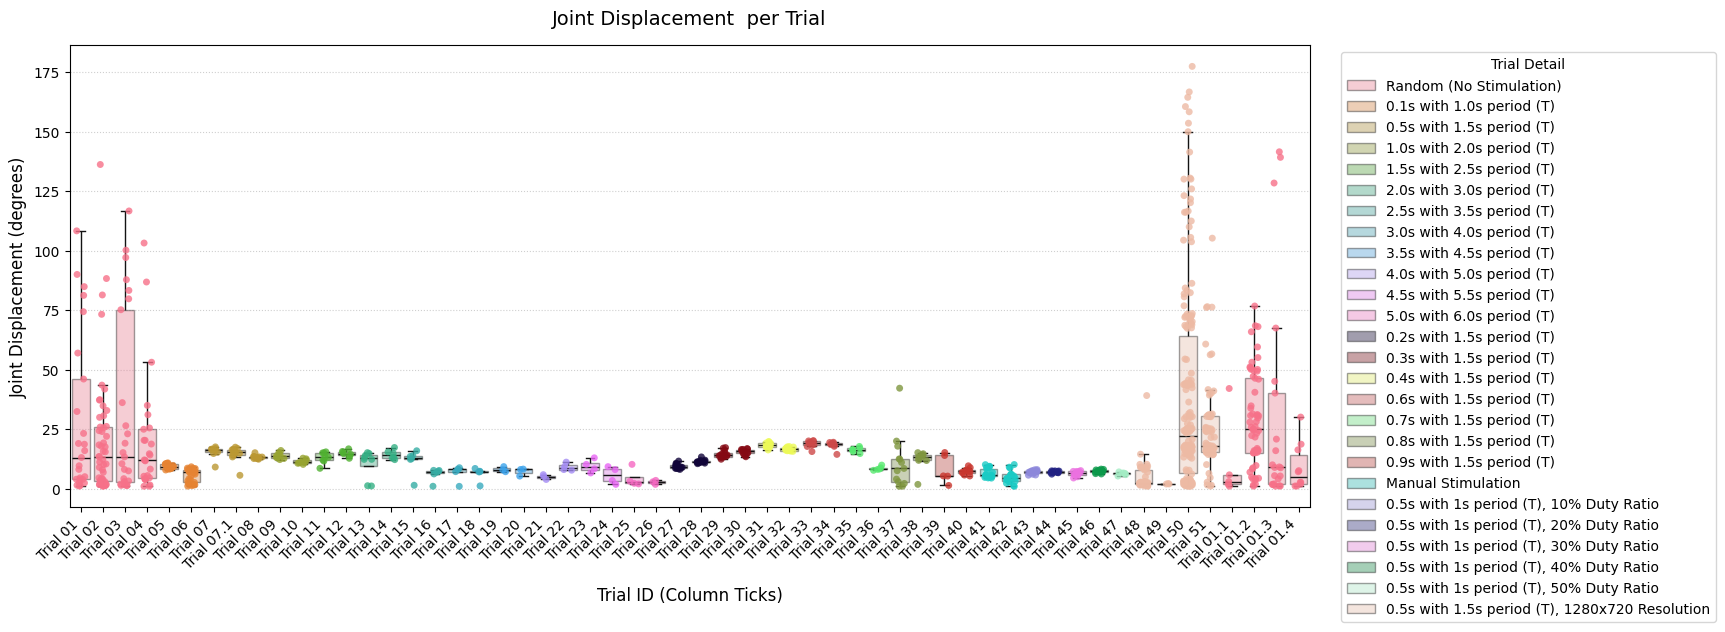

In [57]:
plt.figure(figsize=(16, 6))
# Draw light boxplots for each trial column tick
sns.boxplot(
    data=summary_df, 
    x='Trial', 
    y='Peak_Difference', 
    hue='trial_legend',      # Category mapping for legend
    palette=color_palette,   # Colors pulled directly from summary_df['color']
    boxprops=dict(alpha=0.4),
    showfliers=False
)

# Overlay actual peak points with jitter so every data point is visible
sns.stripplot(
    data=summary_df, 
    x='Trial', 
    y='Peak_Difference', 
    hue='trial_legend', 
    palette=color_palette, 
    dodge=False, 
    size=5, 
    jitter=0.2, 
    alpha=0.8,
    legend=False             # Suppresses duplicate legend entries
)

# Position and format the legend
plt.legend(
    title='Trial Detail', 
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    frameon=True
)

plt.xticks(rotation=45, ha='right')
plt.xlabel('Trial ID (Column Ticks)', fontsize=12, labelpad=10)
plt.ylabel('Joint Displacement (degrees)', fontsize=12)
plt.title('Joint Displacement per Trial', fontsize=14, pad=15)
plt.grid(True, axis='y', linestyle=':', alpha=0.6)